# Beta Scan VAE Training - Using Existing Training Infrastructure
Systematic beta scanning with the existing training function:
- Start with beta=1e-5
- Multiply by 3 each iteration
- Load weights from previous beta run
- Continue until KL < 10 at early stopping

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import time
import nibabel as nib
import json
from tqdm import tqdm
# Import existing training infrastructure
from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.vae.vae_bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckVAE,
)
from models.vae.training import train_vae
from models.vae.config import VAEConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device: cuda


## Define Weighted VAE Loss Function

In [3]:
class WeightedVAELoss(nn.Module):
    """
    Weighted VAE Loss with Luca's improvements:
    - Fixes 3D Axis Mismatch using permute(2, 1, 0)
    - Removes weight normalization
    - Uses 0.1 padding for background
    - Implements Beta Warmup from 0 to beta_final
    """
    def __init__(self, weight_mask_path, beta=0.0005, beta_warmup_steps=5000):
        super().__init__()
        
        # Load the Mask
        weight_nii = nib.load(weight_mask_path)
        weight_data = torch.from_numpy(weight_nii.get_fdata()[:,:,9:73]).float()
        weight_data = weight_data.permute(2, 1, 0)  # Apply same permutation as in loss
        weight_data = weight_data.flip(1)
        weight_data = weight_data.unsqueeze(0).unsqueeze(0)
        weight_data = self.smart_adjust_mask(weight_data,(64,128,128))
        self.weight_data = weight_data# Add batch/channel dims: [1, 1, D, H, W]
        
        # Register as buffer
        self.register_buffer('weight_mask', self.weight_data)
        
        self.beta = beta
        self.beta_warmup_steps = beta_warmup_steps
        self.current_step = 0
        
        print(f"✅ Loss Initialized. Mask Permuted (2,1,0). Shape: {self.weight_mask.shape}")
        print(f"   Beta: 0 → {beta} over {beta_warmup_steps} steps")
        
    def smart_adjust_mask(self, mask, target_shape):
        """
        Adjusts mask to match the input batch size (D, H, W).
        Uses padding value 0.1 for background.
        """
        _, _, D_cur, H_cur, W_cur = mask.shape
        D_tgt, H_tgt, W_tgt = target_shape
        
        # PAD if smaller
        pad_d = max(0, D_tgt - D_cur)
        pad_h = max(0, H_tgt - H_cur)
        pad_w = max(0, W_tgt - W_cur)
        
        if pad_d > 0 or pad_h > 0 or pad_w > 0:
            mask = F.pad(mask, (pad_w//2, pad_w-pad_w//2, 
                                pad_h//2, pad_h-pad_h//2, 
                                pad_d//2, pad_d-pad_d//2), 
                         mode='constant', value=0.1)

        # CROP if larger
        _, _, D_new, H_new, W_new = mask.shape
        d_start = (D_new - D_tgt) // 2
        h_start = (H_new - H_tgt) // 2
        w_start = (W_new - W_tgt) // 2
        
        return mask[:, :, d_start:d_start+D_tgt, h_start:h_start+H_tgt, w_start:w_start+W_tgt]
    
    def __call__(self, recon_x, x, mu, log_var):
        # # Ensure mask is on correct device
        # if self.weight_mask.device != recon_x.device:
        #     self.weight_mask = self.weight_mask.to(recon_x.device)
            
        # current_target_shape = recon_x.shape[2:] 
        
        # # Adjust mask to current batch dimensions if needed
        # if self.weight_mask.shape[2:] != current_target_shape:
        #     adjusted_mask = self.smart_adjust_mask(self.weight_mask, current_target_shape)
        # else:
        #     adjusted_mask = self.weight_mask
            
        # Weighted Reconstruction Loss
        squared_error = (recon_x - x) ** 2
        weighted_error = squared_error * self.weight_mask
        recon_loss = weighted_error.mean()
        
        # KL Divergence
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
        kl_loss = torch.mean(kl_loss)
        
        # Beta Warmup (cycling benefit with initial_beta=0)
        if self.current_step < self.beta_warmup_steps:
            beta = self.beta * (self.current_step / self.beta_warmup_steps)
        else:
            beta = self.beta
            
        self.current_step += 1
        
        # Total Loss
        total_loss = recon_loss + (beta * kl_loss)
        
        return total_loss, recon_loss, kl_loss, beta

## Data Setup

In [4]:
# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/BetaScanVAE"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders - FIX: Set num_workers=0 for Jupyter notebooks
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=0,  # Important: 0 for Jupyter to avoid multiprocessing issues
    shuffle=False # this mapping relies on shuffle=False
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Beta Scan Configuration

In [5]:
# Beta scan parameters
beta_values = [3e-6 ,1e-5, 3e-5, 9e-5, 2.7e-4, 8.1e-4, 2.43e-3, 7.29e-3]
current_beta_index = 0  # Change this to continue from a specific beta
current_beta = beta_values[current_beta_index]

# Directory to store beta scan results
beta_scan_dir = os.path.join(output_dir, "beta_scan_results")
os.makedirs(beta_scan_dir, exist_ok=True)

# Metrics storage for all beta runs
beta_scan_results = {
    'beta': [],
    'final_train_recon': [],
    'final_train_kl': [],
    'final_val_recon': [],
    'final_val_kl': [],
    'final_beta_kl': [],
    'epochs_trained': []
}

# Try to load existing results
summary_path = os.path.join(beta_scan_dir, "beta_scan_summary.json")
if os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        beta_scan_results = json.load(f)
    print(f"✓ Loaded existing beta scan results: {len(beta_scan_results['beta'])} runs completed")

print(f"\nBeta scan configured: {beta_values}")
print(f"Starting with beta = {current_beta:.2e}")
print(f"Results directory: {beta_scan_dir}")

✓ Loaded existing beta scan results: 5 runs completed

Beta scan configured: [3e-06, 1e-05, 3e-05, 9e-05, 0.00027, 0.00081, 0.00243, 0.00729]
Starting with beta = 3.00e-06
Results directory: output/Experiments/BetaScanVAE/beta_scan_results


## Model Setup

In [6]:
target_shape = (64, 128, 128)
latent_dim = 256

def build_vae_model(latent_dim=256):
    """Build BottleneckVAE model"""
    model = BottleneckVAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
        latent_dim=latent_dim
    )
    return model.to(device)

model = build_vae_model(latent_dim=latent_dim)

# Load weights from previous beta run if available
if current_beta_index > 0:
    prev_beta = beta_values[current_beta_index - 1]
    prev_checkpoint = os.path.join(beta_scan_dir, f"beta_{prev_beta:.2e}_best.pth")
    if os.path.exists(prev_checkpoint):
        model.load_state_dict(torch.load(prev_checkpoint, map_location=device))
        print(f"✓ Loaded weights from previous beta run: {prev_checkpoint}")
    else:
        print(f"⚠ Previous checkpoint not found: {prev_checkpoint}")
        print("Training from scratch...")
else:
    print("Starting first beta run from scratch")

num_params = count_trainable(model)
print(f"Model Parameters: {num_params / 1e6:.2f}M")

Starting first beta run from scratch
Model Parameters: 41.34M


## Replace VAELoss in training.py with WeightedVAELoss

In [7]:
# Monkey patch the VAELoss import in the training module
import models.vae.training as training_module
training_module.VAELoss = WeightedVAELoss

print("✓ Replaced VAELoss with WeightedVAELoss in training module")

✓ Replaced VAELoss with WeightedVAELoss in training module


## Training Configuration

In [8]:
# Create VAE config for current beta
config = VAEConfig(
    latent_dim=latent_dim,
    learning_rate=1e-4,
    batch_size=batch_size,
    accumulation_steps=1,  # No accumulation since we're using batch_size=4
    epochs=150,
    early_stopping_patience=20,
    beta=current_beta,
    beta_warmup_steps=5000,
    use_mixed_precision=True,
    gradient_clip=1.0,
    num_workers=0,  # Important for Jupyter
    checkpoint_dir=os.path.join(beta_scan_dir, f"beta_{current_beta:.2e}"),
    model_name=f"beta_{current_beta:.2e}",
    save_interval=10
)

# Pass weight_mask_path to the loss function
# This will be used when VAELoss is instantiated in train_vae
config.weight_mask_path = "data/masks/weightMatrix.nii"


VAE TRAINING CONFIGURATION
Model: beta_3.00e-06 with latent dim 256
Batch size: 4 × 1 steps = 4 effective
Learning rate: 0.0001
Beta (KL weight): 3e-06 with 5000 warmup steps
Mixed precision: Enabled
Epochs: 150 with patience 20
Dataloader workers: 0
Checkpoints saved to: output/Experiments/BetaScanVAE/beta_scan_results/beta_3.00e-06



## Custom Training Function with WeightedVAELoss

In [8]:
# We need to modify the train_vae function to use WeightedVAELoss
# Let's create a wrapper that initializes the criterion correctly

from torch.cuda import amp
from models.vae.optimizer import create_vae_optimizer
from models.vae.scheduler import create_vae_scheduler
from models.vae.config import VAECheckpointHandler, VAEEarlyStopping
from tqdm import tqdm
import gc

def train_vae_beta_scan(model, train_loader, val_loader, config):
    """Modified training function using WeightedVAELoss"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Initialize WeightedVAELoss instead of VAELoss
    criterion = WeightedVAELoss(
        weight_mask_path=config.weight_mask_path,
        beta=config.beta,
        beta_warmup_steps=config.beta_warmup_steps
    ).to(device)
    
    optimizer = create_vae_optimizer(model, config)
    scheduler = create_vae_scheduler(optimizer, config)
    scheduler.threshold = 1e-5
    scheduler.threshold_mode='abs'
    early_stopping = VAEEarlyStopping(patience=config.early_stopping_patience,min_delta=1e-5)
    checkpoint_handler = VAECheckpointHandler(config.checkpoint_dir, config.model_name)

    # Mixed precision setup
    scaler = amp.GradScaler(enabled=config.use_mixed_precision)

    # Training tracking variables
    train_losses = []
    val_losses = []
    train_recon_losses = []
    train_kl_losses = []
    val_recon_losses = []
    val_kl_losses = []
    best_val_loss = float('inf')
    start_time = time.time()

    # Training loop
    print(f"\n{'='*60}")
    print(f"Starting training for beta = {config.beta:.2e}")
    print(f"{'='*60}\n")
    
    for epoch in range(config.epochs):
        # Training phase
        model.train()
        epoch_loss = 0
        epoch_recon_loss = 0
        epoch_kl_loss = 0
        current_beta = 0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{config.epochs} [Train]', leave=True)

        for batch_idx, batch in enumerate(train_pbar):
            volumes = batch['volume'].to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            # Forward pass
            with amp.autocast(enabled=config.use_mixed_precision):
                reconstructed, mu, log_var = model(volumes)
                loss, recon_loss, kl_loss, beta = criterion(reconstructed, volumes, mu, log_var)
                current_beta = beta

            # Backward pass
            scaler.scale(loss).backward()
            
            if config.gradient_clip > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
            
            scaler.step(optimizer)
            scaler.update()

            # Track loss
            epoch_loss += loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            train_pbar.set_postfix({
                'loss': f"{loss.item():.6f}",
                'recon': f"{recon_loss.item():.6f}",
                'kl': f"{kl_loss.item():.2f}",
                'beta': f"{beta:.6f}"
            })

            del volumes, reconstructed, mu, log_var, loss, recon_loss, kl_loss

        # Calculate average training losses
        avg_train_loss = epoch_loss / len(train_loader)
        avg_train_recon_loss = epoch_recon_loss / len(train_loader)
        avg_train_kl_loss = epoch_kl_loss / len(train_loader)
        
        train_losses.append(avg_train_loss)
        train_recon_losses.append(avg_train_recon_loss)
        train_kl_losses.append(avg_train_kl_loss)

        # Validation phase
        model.eval()
        val_loss = 0
        val_recon_loss_sum = 0
        val_kl_loss_sum = 0
        
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{config.epochs} [Val]', leave=True)

        with torch.no_grad():
            for batch in val_pbar:
                volumes = batch['volume'].to(device)
                reconstructed, mu, log_var = model(volumes)
                loss, recon_loss, kl_loss, _ = criterion(reconstructed, volumes, mu, log_var)
                
                val_loss += loss.item()
                val_recon_loss_sum += recon_loss.item()
                val_kl_loss_sum += kl_loss.item()
                
                val_pbar.set_postfix({
                    'loss': f"{loss.item():.6f}",
                    'recon': f"{recon_loss.item():.6f}",
                    'kl': f"{kl_loss.item():.2f}"
                })

                del volumes, reconstructed, mu, log_var, loss, recon_loss, kl_loss

        # Calculate average validation losses
        avg_val_loss = val_loss / len(val_loader)
        avg_val_recon_loss = val_recon_loss_sum / len(val_loader)
        avg_val_kl_loss = val_kl_loss_sum / len(val_loader)
        
        val_losses.append(avg_val_loss)
        val_recon_losses.append(avg_val_recon_loss)
        val_kl_losses.append(avg_val_kl_loss)
        is_best= False
        if (epoch > 7):
            # Update learning rate
            scheduler.step(avg_val_loss)

         
    
            # Check if this is the best model
            is_best = avg_val_loss < best_val_loss
            if is_best:
                best_val_loss = avg_val_loss
                # Save best model to beta_scan_dir root
                best_model_path = os.path.join(beta_scan_dir, f"beta_{config.beta:.2e}_best.pth")
                torch.save(model.state_dict(), best_model_path)
            # Early stopping check
            early_stopping(avg_val_loss, epoch)
            if early_stopping.early_stop:
                print("\nEarly stopping triggered!")
                break                   

        # Save checkpoint
        if (epoch + 1) % config.save_interval == 0 or is_best:
            checkpoint_handler.save(
                model, optimizer, scheduler,
                epoch, train_losses, val_losses, 
                train_recon_losses, train_kl_losses,
                val_recon_losses, val_kl_losses,
                is_best=is_best
            )

        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{config.epochs}:")
        print(f"Train Loss: {avg_train_loss:.6f} (Recon: {avg_train_recon_loss:.6f}, KL: {avg_train_kl_loss:.2f})")
        print(f"Val Loss: {avg_val_loss:.6f} (Recon: {avg_val_recon_loss:.6f}, KL: {avg_val_kl_loss:.2f})")
        print(f"Beta*KL: {config.beta * avg_val_kl_loss:.6f}")
        print(f"LR: {optimizer.param_groups[0]['lr']:.8f}\n")
        

    total_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"✓ Training completed in {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"Best validation loss: {best_val_loss:.6f}")
    print(f"Final validation KL: {val_kl_losses[-1]:.2f}")
    print(f"{'='*60}\n")
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_recon_losses': train_recon_losses,
        'train_kl_losses': train_kl_losses,
        'val_recon_losses': val_recon_losses,
        'val_kl_losses': val_kl_losses,
        'best_val_loss': best_val_loss,
        'model': model
    }

## Run Training

In [9]:
# # Train the model
# results = train_vae_beta_scan(model, train_loader, val_loader, config)

# # Store results for this beta
# beta_scan_results['beta'].append(current_beta)
# beta_scan_results['final_train_recon'].append(results['train_recon_losses'][-1])
# beta_scan_results['final_train_kl'].append(results['train_kl_losses'][-1])
# beta_scan_results['final_val_recon'].append(results['val_recon_losses'][-1])
# beta_scan_results['final_val_kl'].append(results['val_kl_losses'][-1])
# beta_scan_results['final_beta_kl'].append(current_beta * results['val_kl_losses'][-1])
# beta_scan_results['epochs_trained'].append(len(results['train_losses']))

# # Save beta scan summary
# with open(summary_path, 'w') as f:
#     json.dump(beta_scan_results, f, indent=2)
# print(f"✓ Beta scan summary saved: {summary_path}")

# # Decision guidance
# final_kl = results['val_kl_losses'][-1]
# print(f"\n{'='*60}")
# print("NEXT STEPS:")
# if final_kl > 10:
#     print(f"✓ KL={final_kl:.2f} > 10: Continue to next beta")
#     print(f"  Set current_beta_index = {current_beta_index + 1}")
#     if current_beta_index + 1 < len(beta_values):
#         print(f"  Next beta: {beta_values[current_beta_index + 1]:.2e}")
# else:
#     print(f"✓ KL={final_kl:.2f} < 10: Beta scan complete!")
#     print("  Proceed to analysis and visualization")
# print(f"{'='*60}\n")

In [10]:
current_beta_index=2

In [ ]:
# Automated Beta Scan Loop
print(f"\\n{'='*80}")
print(f"STARTING AUTOMATED BETA SCAN")
print(f"{'='*80}")
print(f"Beta values: {beta_values}")
print(f"Starting from index: {current_beta_index}")
print(f"{'='*80}\\n")

# Loop through all beta values starting from current_beta_index
for beta_idx in range(current_beta_index, len(beta_values)):
    current_beta = beta_values[beta_idx]
    
    print(f"\\n{'='*60}")
    print(f"TRAINING BETA {beta_idx+1}/{len(beta_values)}: {current_beta:.2e}")
    print(f"{'='*60}\\n")
    
    # Update config for current beta
    config.beta = current_beta
    config.checkpoint_dir = os.path.join(beta_scan_dir, f"beta_{current_beta:.2e}")
    config.model_name = f"beta_{current_beta:.2e}"
    
    # Rebuild model for this beta (or load from previous)
    model = build_vae_model(latent_dim=latent_dim)
    
    # Load weights from previous beta run if available
    if beta_idx > 0:
        prev_beta = beta_values[beta_idx - 1]
        prev_checkpoint = os.path.join(beta_scan_dir, f"beta_{prev_beta:.2e}_best.pth")
        if os.path.exists(prev_checkpoint):
            model.load_state_dict(torch.load(prev_checkpoint, map_location=device))
            print(f"✓ Loaded weights from previous beta run: {prev_checkpoint}")
        else:
            print(f"⚠ Previous checkpoint not found: {prev_checkpoint}")
            print("Training from scratch...")
    else:
        print("Starting first beta run from scratch")
    
    # Train the model
    results = train_vae_beta_scan(model, train_loader, val_loader, config)
    
    # Store results for this beta
    beta_scan_results['beta'].append(current_beta)
    beta_scan_results['final_train_recon'].append(results['train_recon_losses'][-1])
    beta_scan_results['final_train_kl'].append(results['train_kl_losses'][-1])
    beta_scan_results['final_val_recon'].append(results['val_recon_losses'][-1])
    beta_scan_results['final_val_kl'].append(results['val_kl_losses'][-1])
    beta_scan_results['final_beta_kl'].append(current_beta * results['val_kl_losses'][-1])
    beta_scan_results['epochs_trained'].append(len(results['train_losses']))
    
    # Save beta scan summary after each run
    with open(summary_path, 'w') as f:
        json.dump(beta_scan_results, f, indent=2)
    print(f"✓ Beta scan summary saved: {summary_path}")
    
    # Check stopping condition
    final_kl = results['val_kl_losses'][-1]
    print(f"\\n{'='*60}")
    print(f"BETA {beta_idx+1} RESULTS:")
    print(f"Final KL: {final_kl:.2f}")
    print(f"Final Beta*KL: {current_beta * final_kl:.6f}")
    print(f"Epochs trained: {len(results['train_losses'])}")
    
    if final_kl < 10:
        print(f"\\n✓ KL={final_kl:.2f} < 10: BETA SCAN COMPLETE!")
        print(f"Optimal beta found: {current_beta:.2e}")
        break
    else:
        print(f"\\n✓ KL={final_kl:.2f} > 10: Continuing to next beta...")
        if beta_idx + 1 < len(beta_values):
            print(f"Next beta: {beta_values[beta_idx + 1]:.2e}")
        else:
            print("Reached maximum beta value. Scan complete.")
    
    print(f"{'='*60}\\n")

print(f"\\n{'='*80}")
print(f"BETA SCAN COMPLETE!")
print(f"Total runs completed: {len(beta_scan_results['beta'])}")
print(f"{'='*80}\\n")

\n================================================================================
STARTING AUTOMATED BETA SCAN
Beta values: [3e-06, 1e-05, 3e-05, 9e-05, 0.00027, 0.00081, 0.00243, 0.00729]
Starting from index: 2
================================================================================\n
\n============================================================
TRAINING BETA 3/8: 3.00e-05
============================================================\n
✓ Loaded weights from previous beta run: output/Experiments/BetaScanVAE/beta_scan_results/beta_1.00e-05_best.pth
✅ Loss Initialized. Mask Permuted (2,1,0). Shape: torch.Size([1, 1, 64, 128, 128])
   Beta: 0 → 3e-05 over 5000 steps


/tmp/ipykernel_2414/2382317044.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=config.use_mixed_precision)



Starting training for beta = 3.00e-05



/tmp/ipykernel_2414/2382317044.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=config.use_mixed_precision):
Epoch 1/150 [Val]: 100%|████████████████████| 149/149 [00:59<00:00,  2.52it/s, loss=0.004828, recon=0.004299, kl=118.64]



Epoch 1/150:
Train Loss: 0.003785 (Recon: 0.003541, KL: 150.87)
Val Loss: 0.004228 (Recon: 0.003779, KL: 111.76)
Beta*KL: 0.003353
LR: 0.00010000



...

Epoch 10/150 [Val]: 100%|████████████████████| 149/149 [00:14<00:00, 10.47it/s, loss=0.006024, recon=0.004838, kl=39.53]


Validation loss improved by 0.000078
Saved best model to output/Experiments/BetaScanVAE/beta_scan_results/beta_3.00e-05/beta_3.00e-05_best.pth

Epoch 10/150:
Train Loss: 0.005745 (Recon: 0.004582, KL: 38.79)
Val Loss: 0.005378 (Recon: 0.004256, KL: 37.40)
Beta*KL: 0.001122
LR: 0.00010000



Epoch 11/150 [Val]: 100%|████████████████████| 149/149 [00:13<00:00, 11.31it/s, loss=0.005900, recon=0.004778, kl=37.39]


Validation loss improved by 0.000099
Saved best model to output/Experiments/BetaScanVAE/beta_scan_results/beta_3.00e-05/beta_3.00e-05_best.pth

Epoch 11/150:
Train Loss: 0.005794 (Recon: 0.004620, KL: 39.13)
Val Loss: 0.005279 (Recon: 0.004216, KL: 35.44)
Beta*KL: 0.001063
LR: 0.00010000



Epoch 12/150 [Train]:   2%|    | 12/595 [00:01<01:01,  9.47it/s, loss=0.007173, recon=0.005930, kl=41.42, beta=0.000030]

In [ ]:
# Plot training curves for current beta

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

train_losses = results['train_losses']
val_losses = results['val_losses']

train_recon_losses = results['train_recon_losses']
val_recon_losses = results['val_recon_losses']

train_kl_losses = results['train_kl_losses']
val_kl_losses = results['val_kl_losses']

epochs = range(1, len(train_losses) + 1)

# Total Loss
axes[0, 0].plot(epochs, train_losses, label='Train', linewidth=2)
axes[0, 0].plot(epochs, val_losses, label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title(f'Total Loss (Beta={current_beta:.2e})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction Loss
axes[0, 1].plot(epochs, train_recon_losses, label='Train', linewidth=2)
axes[0, 1].plot(epochs, val_recon_losses, label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss')
axes[0, 1].set_title('Reconstruction Loss', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# KL Divergence
axes[1, 0].plot(epochs, train_kl_losses, label='Train', linewidth=2)
axes[1, 0].plot(epochs, val_kl_losses, label='Val', linewidth=2)
axes[1, 0].axhline(y=10, color='r', linestyle='--', label='KL=10 threshold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL Divergence')
axes[1, 0].set_title('KL Divergence', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Beta * KL
beta_kl_train = [current_beta * kl for kl in train_kl_losses]
beta_kl_val = [current_beta * kl for kl in val_kl_losses]
axes[1, 1].plot(epochs, beta_kl_train, label='Train', linewidth=2)
axes[1, 1].plot(epochs, beta_kl_val, label='Val', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Beta * KL')
axes[1, 1].set_title('Beta * KL Divergence', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(output_dir, f"training_curves_beta_{current_beta:.2e}.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Training curves saved: {plot_path}")

## Beta Scan Summary and Analysis

In [9]:
# Load beta scan summary
if os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        beta_scan_results = json.load(f)
    
    print("Beta Scan Results Summary:")
    print("="*80)
    print(f"{'Beta':<12} {'Val Recon':<12} {'Val KL':<10} {'Beta*KL':<12} {'Epochs':<8}")
    print("="*80)
    for i, beta in enumerate(beta_scan_results['beta']):
        print(f"{beta:<12.2e} {beta_scan_results['final_val_recon'][i]:<12.6f} "
              f"{beta_scan_results['final_val_kl'][i]:<10.2f} "
              f"{beta_scan_results['final_beta_kl'][i]:<12.6f} "
              f"{beta_scan_results['epochs_trained'][i]:<8}")
    print("="*80)
else:
    print("No beta scan summary found. Run training first.")

Beta Scan Results Summary:
Beta         Val Recon    Val KL     Beta*KL      Epochs  
3.00e-06     0.003596     133.19     0.000400     148     
1.00e-05     0.003681     68.33      0.000683     71      
3.00e-05     0.003980     33.35      0.001000     68      
9.00e-05     0.004444     17.13      0.001542     56      
2.70e-04     0.005276     8.38       0.002264     42      


## Beta Scan Visualization

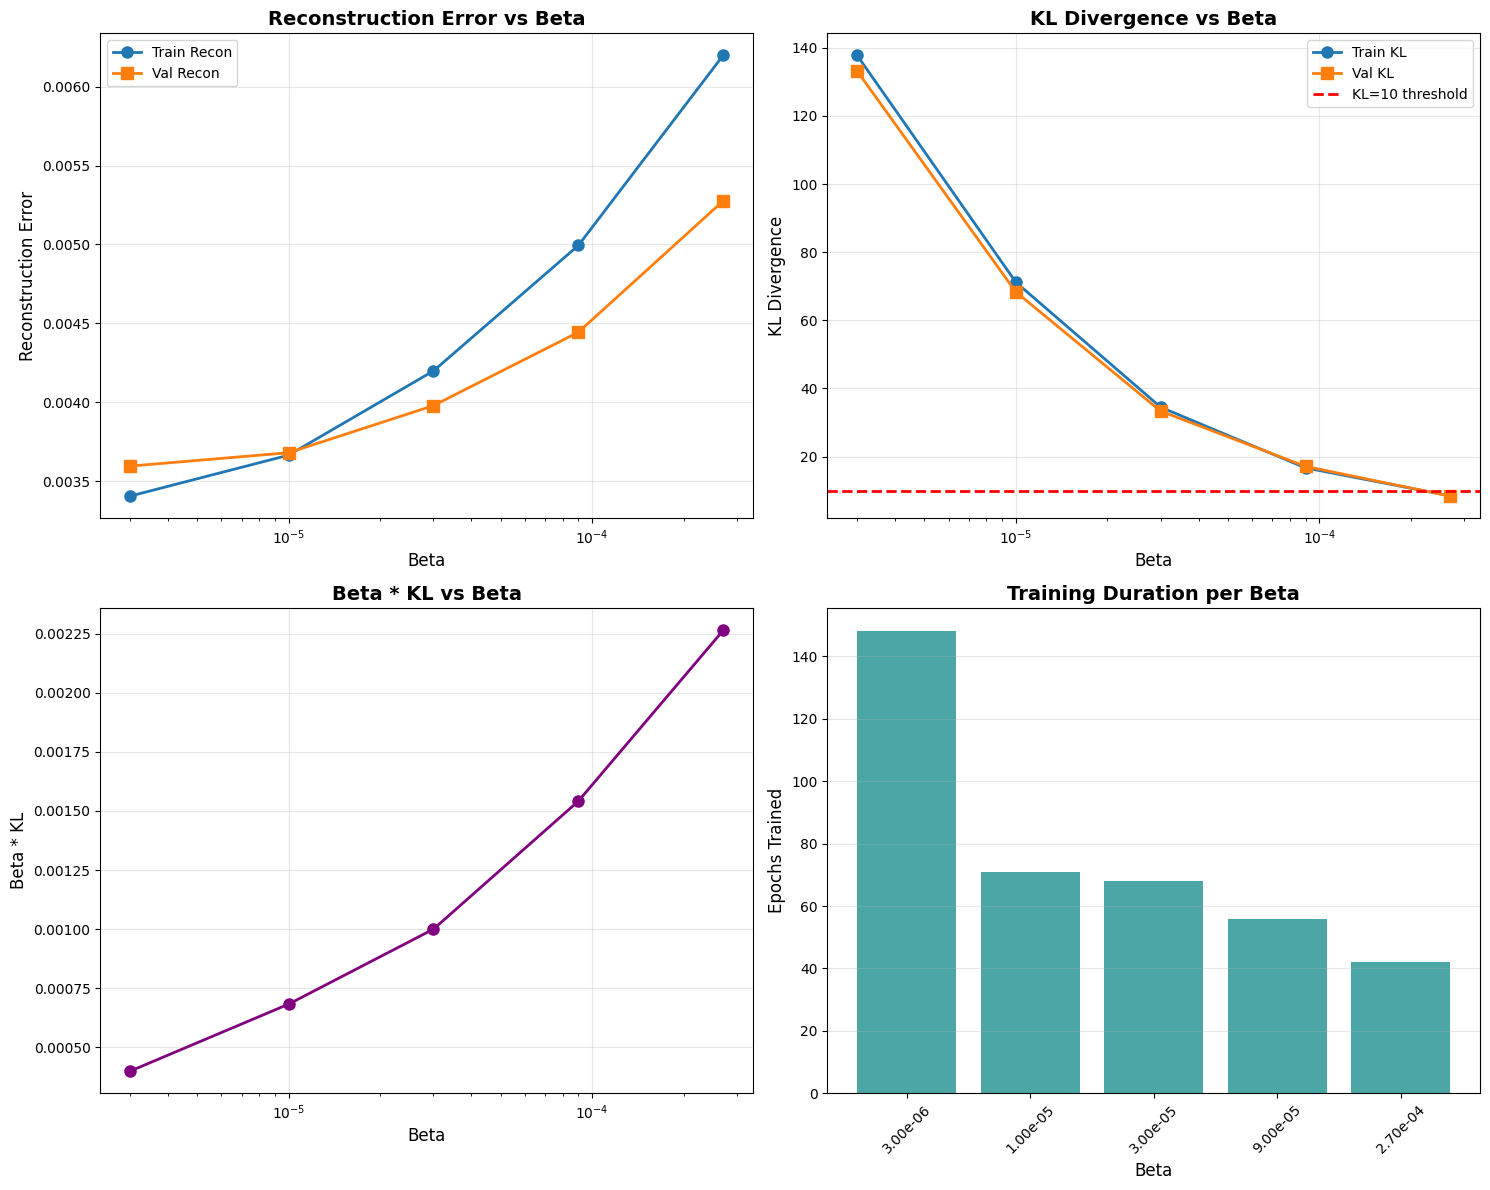

✓ Beta scan plot saved: output/Experiments/BetaScanVAE/beta_scan_results/beta_scan_analysis.png


In [10]:
# Plot beta scan results across all beta values
if len(beta_scan_results['beta']) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    betas = beta_scan_results['beta']
    
    # Plot 1: Reconstruction Error vs Beta
    axes[0, 0].plot(betas, beta_scan_results['final_train_recon'], 'o-', label='Train Recon', linewidth=2, markersize=8)
    axes[0, 0].plot(betas, beta_scan_results['final_val_recon'], 's-', label='Val Recon', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Beta', fontsize=12)
    axes[0, 0].set_ylabel('Reconstruction Error', fontsize=12)
    axes[0, 0].set_xscale('log')
    axes[0, 0].set_title('Reconstruction Error vs Beta', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: KL Divergence vs Beta
    axes[0, 1].plot(betas, beta_scan_results['final_train_kl'], 'o-', label='Train KL', linewidth=2, markersize=8)
    axes[0, 1].plot(betas, beta_scan_results['final_val_kl'], 's-', label='Val KL', linewidth=2, markersize=8)
    axes[0, 1].axhline(y=10, color='r', linestyle='--', linewidth=2, label='KL=10 threshold')
    axes[0, 1].set_xlabel('Beta', fontsize=12)
    axes[0, 1].set_ylabel('KL Divergence', fontsize=12)
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_title('KL Divergence vs Beta', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Beta * KL vs Beta
    axes[1, 0].plot(betas, beta_scan_results['final_beta_kl'], 'o-', color='purple', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Beta', fontsize=12)
    axes[1, 0].set_ylabel('Beta * KL', fontsize=12)
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_title('Beta * KL vs Beta', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Epochs Trained vs Beta
    axes[1, 1].bar(range(len(betas)), beta_scan_results['epochs_trained'], color='teal', alpha=0.7)
    axes[1, 1].set_xlabel('Beta', fontsize=12)
    axes[1, 1].set_ylabel('Epochs Trained', fontsize=12)
    axes[1, 1].set_title('Training Duration per Beta', fontsize=14, fontweight='bold')
    axes[1, 1].set_xticks(range(len(betas)))
    axes[1, 1].set_xticklabels([f"{b:.2e}" for b in betas], rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plot_path = os.path.join(beta_scan_dir, "beta_scan_analysis.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Beta scan plot saved: {plot_path}")
else:
    print("Need at least 2 beta runs to plot comparison")

## Mask Alignment Verification

Verifying mask alignment...
✅ Loss Initialized. Mask Permuted (2,1,0). Shape: torch.Size([1, 1, 64, 128, 128])
   Beta: 0 → 1e-05 over 5000 steps


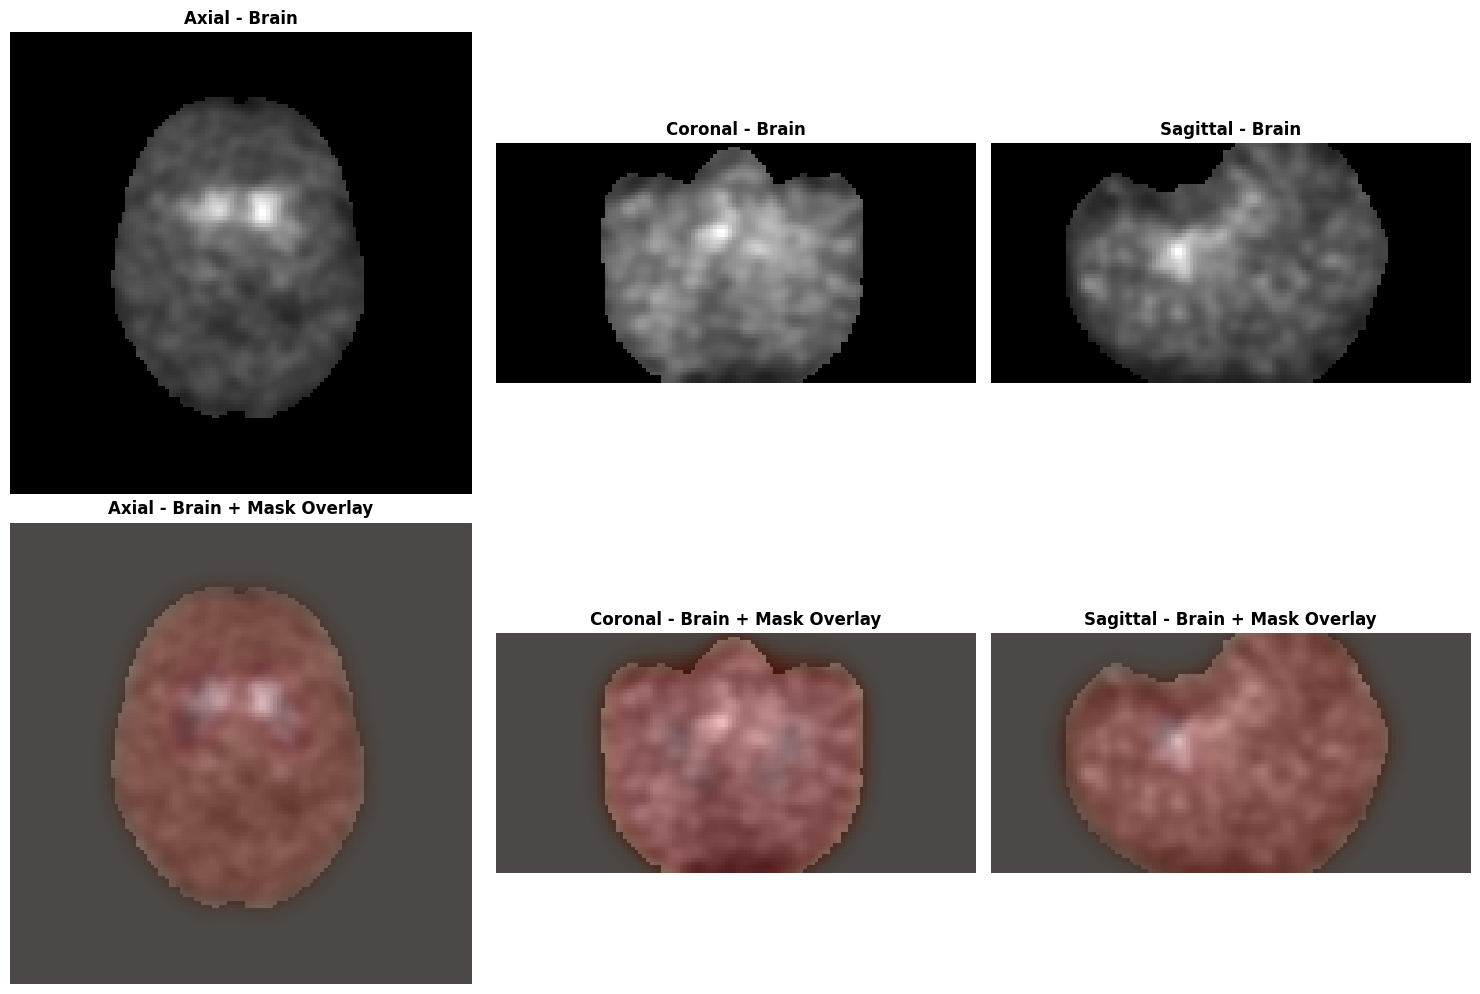

✓ Mask alignment verification saved: output/Experiments/BetaScanVAE/mask_alignment_verification.png

Check if mask aligns properly with brain structures (no flipping)


In [18]:
# Verify mask alignment with brain image
print("Verifying mask alignment...")

# Load mask
mask_nii = nib.load("data/masks/weightMatrix.nii")
mask_data = torch.from_numpy(mask_nii.get_fdata()[:,:,9:73]).float()
mask_data = mask_data.permute(2, 1, 0)  # Apply same permutation as in loss
mask_data = mask_data.flip(1)
# Load a sample brain
sample_batch = next(iter(val_loader))
sample_brain = sample_batch['volume'][0, 0].cpu().numpy()  # [D, H, W]

# Create a temporary criterion to use smart_adjust_mask
temp_criterion = WeightedVAELoss("data/masks/weightMatrix.nii", beta=1e-5)
mask_adjusted = temp_criterion.smart_adjust_mask(
    mask_data.unsqueeze(0).unsqueeze(0), 
    sample_brain.shape
)[0, 0].cpu().numpy()

# Plot overlay on multiple slices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

slice_positions = [
    ('Axial', 0, sample_brain.shape[0]//2),
    ('Coronal', 1, sample_brain.shape[1]//2),
    ('Sagittal', 2, sample_brain.shape[2]//2)
]

for idx, (plane, axis, pos) in enumerate(slice_positions):
    # Get slices
    if axis == 0:
        brain_slice = sample_brain[pos, :, :]
        mask_slice = mask_adjusted[pos, :, :]
    elif axis == 1:
        brain_slice = sample_brain[:, pos, :]
        mask_slice = mask_adjusted[:, pos, :]
    else:
        brain_slice = sample_brain[:, :, pos]
        mask_slice = mask_adjusted[:, :, pos]
    
    # Brain only
    axes[0, idx].imshow(brain_slice, cmap='gray')
    axes[0, idx].set_title(f'{plane} - Brain', fontsize=12, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Overlay
    axes[1, idx].imshow(brain_slice, cmap='gray')
    axes[1, idx].imshow(mask_slice, cmap='Reds', alpha=0.3)
    axes[1, idx].set_title(f'{plane} - Brain + Mask Overlay', fontsize=12, fontweight='bold')
    axes[1, idx].axis('off')

plt.tight_layout()
overlay_path = os.path.join(output_dir, "mask_alignment_verification.png")
plt.savefig(overlay_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Mask alignment verification saved: {overlay_path}")
print("\nCheck if mask aligns properly with brain structures (no flipping)")

Loaded best model from: output/Experiments/BetaScanVAE/beta_scan_results/beta_3.00e-06_best.pth


NameError: name 'checkpoint_dir' is not defined

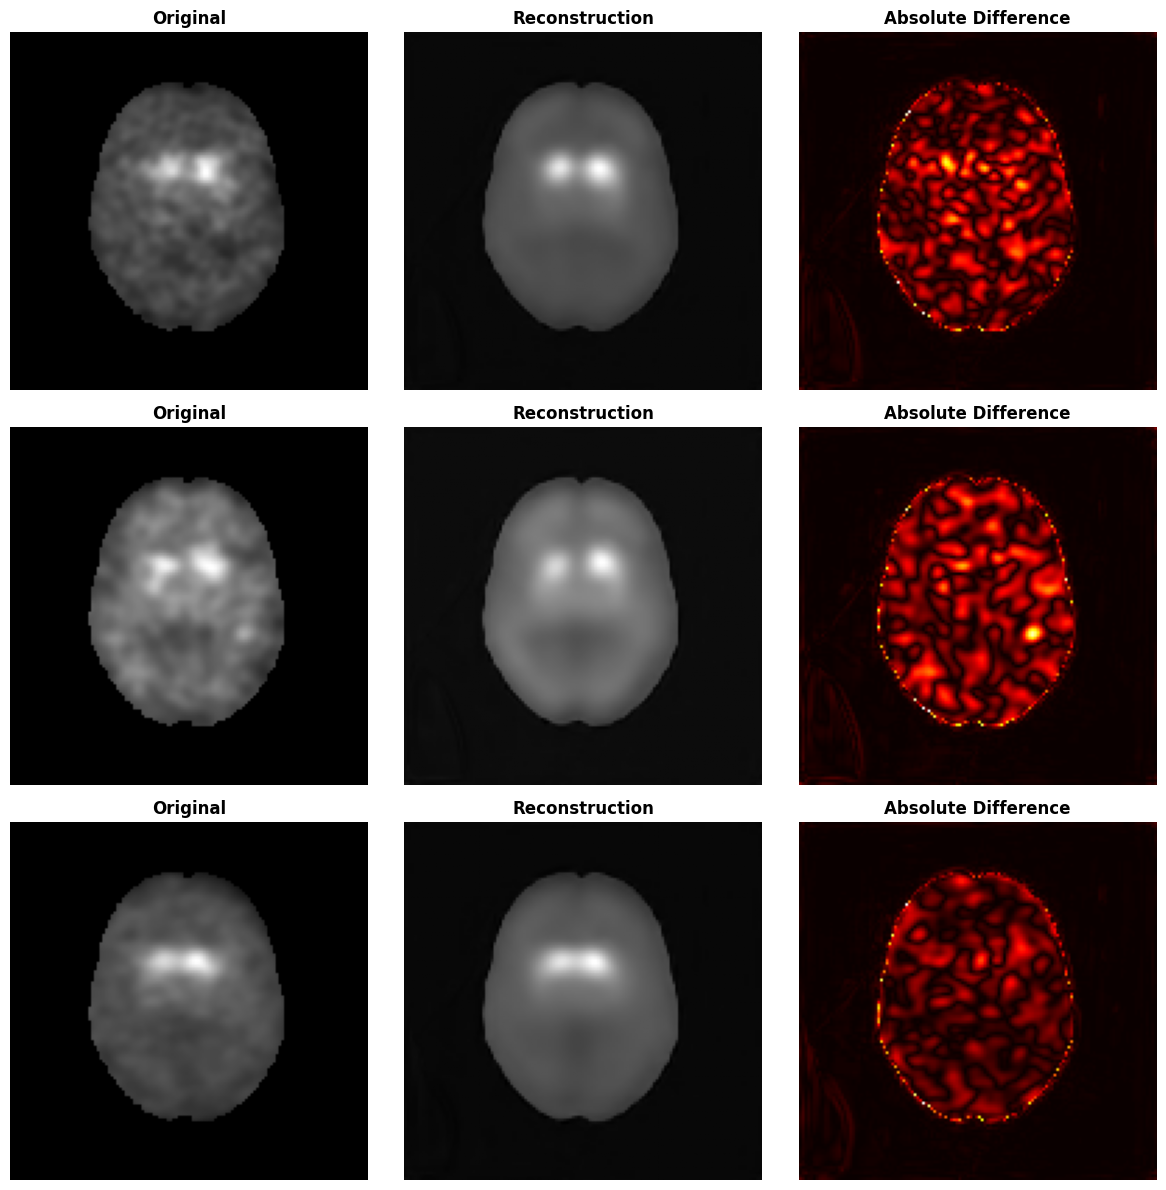

In [19]:
# Load best model from current beta
best_model = build_vae_model(latent_dim=latent_dim)
best_model_path = os.path.join(beta_scan_dir, f"beta_{current_beta:.2e}_best.pth")
if os.path.exists(best_model_path):
    best_model.load_state_dict(torch.load(best_model_path))
    print(f"Loaded best model from: {best_model_path}")
else:
    print("Best model not found, using current model")
    best_model = model

best_model.eval()

# Get sample data
num_samples = 3
sample_batch = next(iter(val_loader))
sample_data = sample_batch['volume'][:num_samples].to(device)

# Generate reconstructions
with torch.no_grad():
    recons, _, _ = best_model(sample_data)

# Visualization
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for i in range(num_samples):
    # Extract middle slices
    orig = sample_data[i, 0].cpu().numpy()
    recon = recons[i, 0].cpu().numpy()
    diff = np.abs(orig - recon)
    
    mid_slice = orig.shape[0] // 2
    
    # Original
    axes[i, 0].imshow(orig[mid_slice], cmap='gray')
    axes[i, 0].set_title('Original', fontweight='bold')
    axes[i, 0].axis('off')
    
    # Reconstruction
    axes[i, 1].imshow(recon[mid_slice], cmap='gray')
    axes[i, 1].set_title('Reconstruction', fontweight='bold')
    axes[i, 1].axis('off')
    
    # Difference
    axes[i, 2].imshow(diff[mid_slice], cmap='hot')
    axes[i, 2].set_title('Absolute Difference', fontweight='bold')
    axes[i, 2].axis('off')

plt.tight_layout()
recon_path = os.path.join(checkpoint_dir, f"reconstructions_beta_{current_beta:.2e}.png")
plt.savefig(recon_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Reconstructions saved: {recon_path}")

## Analyse

In [11]:
def analyze_latent_space(beta_values, beta_scan_dir, train_loader, val_loader, device, latent_dim=256, threshold=0.05):
    """
    Analyzes KL divergence per dimension and saves latent mu representations.
    """
    results = {
        'beta': [],
        'active_units': [],
        'avg_kl': []
    }
    
    # Ensure output directories exist for mu CSVs
    mu_save_dir = os.path.join(os.path.dirname(beta_scan_dir), "latent_representations")
    os.makedirs(mu_save_dir, exist_ok=True)
    
    print(f"Starting KL Analysis. Threshold for active units: {threshold}")
    print(f"Saving Mu CSVs to: {mu_save_dir}\n")

    for beta in beta_values:
        print(f"Processing Beta: {beta:.2e}")
        
        # 1. Load the Best Model for this Beta
        # Re-build model structure (assuming standard build_vae_model exists in your scope)
        model = build_vae_model(latent_dim=latent_dim).to(device)
        
        checkpoint_path = os.path.join(beta_scan_dir, f"beta_{beta:.2e}_best.pth")
        if not os.path.exists(checkpoint_path):
            print(f"⚠️ Checkpoint not found for beta {beta:.2e}, skipping...")
            continue
            
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()
        
        # 2. Extract Mu and Compute KL for Training Set
        train_mus = []
        train_kl_dims = []
        train_metadata = []
        
        with torch.no_grad():
            for batch in tqdm(train_loader, desc=f"Extracting Train (KL & Mu) (Beta: {beta:.2e})"):
                imgs = batch['volume'].to(device)
                
                # Forward pass to get mu and logvar
                # Note: We rely on the model returning (recon, mu, log_var)
                _, mu, log_var = model(imgs)
                
                # Calculate KL per dimension for this batch
                # Formula: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
                # We want mean over batch axis (0), keeping feature axis (1)
                kl_elementwise = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
                
                train_mus.append(mu.cpu().numpy())
                train_kl_dims.append(kl_elementwise.cpu().numpy())

                # We assume batch contains 'PATNO', 'path', or 'label' keys
                batch_size = imgs.size(0)
                for i in range(batch_size):
                    meta_entry = {}
                    if 'path' in batch:
                        val = batch['path'][i]
                        meta_entry['file_path'] = val
                        meta_entry['PATNO'] = val.split('/')[-5]
                    if 'label' in batch:
                        val = batch['label'][i]
                        meta_entry['label'] = val.item() if hasattr(val, 'item') else val
                    
                    train_metadata.append(meta_entry)

        # Concatenate results
        train_mus = np.vstack(train_mus)
        all_kls = np.vstack(train_kl_dims) # Shape: (N_samples, Latent_Dim)
        
        # Compute mean KL per dimension over the whole dataset
        mean_kl_per_dim = np.mean(all_kls, axis=0) # Shape: (Latent_Dim,)
        
        # Count active units
        active_mask = mean_kl_per_dim > threshold
        n_active = np.sum(active_mask)
        avg_kl_val = np.mean(mean_kl_per_dim)
        
        results['beta'].append(beta)
        results['active_units'].append(n_active)
        results['avg_kl'].append(avg_kl_val)
        
        print(f"  -> Active Units (> {threshold}): {n_active}/{latent_dim}")
        
        # 3. Save Training Mu to CSV
        # We try to attach file_paths if they exist in the dataset, otherwise just indices
        train_df_mu = pd.DataFrame(train_mus, columns=[f"latent_{i}" for i in range(latent_dim)])
        # Assuming the loader follows the order of the dataframe provided to it
        # If your loader shuffles, this mapping relies on shuffle=False or careful index tracking.
        # For analysis of distribution, raw values are fine.
        train_df_meta = pd.DataFrame(train_metadata)
        train_df_final = pd.concat([train_df_meta, train_df_mu], axis=1) # Side-by-side concat
        
        train_csv_path = os.path.join(mu_save_dir, f"train_mu_beta_{beta:.2e}.csv")
        train_df_final.to_csv(train_csv_path, index=False)
        
        # 4. Extract and Save Validation Mu (only extraction needed)
        val_mus = []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Extracting Val (Mu)"):
                imgs = batch['volume'].to(device)
                _, mu, _ = model(imgs)
                val_mus.append(mu.cpu().numpy())
        
        val_mus = np.vstack(val_mus)
        val_df_mu = pd.DataFrame(val_mus, columns=[f"latent_{i}" for i in range(latent_dim)])
        val_csv_path = os.path.join(mu_save_dir, f"val_mu_beta_{beta:.2e}.csv")
        val_df_mu.to_csv(val_csv_path, index=False)
        print(f"  -> Saved CSVs to {mu_save_dir}")

    return pd.DataFrame(results)

# --- EXECUTE ANALYSIS ---
# Run the analysis
kl_results_df = analyze_latent_space(
    beta_values=beta_values, 
    beta_scan_dir=os.path.join(output_dir, "beta_scan_results"), # Adjust if your path differs
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    latent_dim=latent_dim
)

Starting KL Analysis. Threshold for active units: 0.05
Saving Mu CSVs to: output/Experiments/BetaScanVAE/latent_representations

Processing Beta: 3.00e-06


Extracting Train (KL & Mu) (Beta: 3.00e-06): 100%|██████████████████████████████| 595/595 [00:47<00:00, 12.42it/s]


  -> Active Units (> 0.05): 256/256


Extracting Val (Mu): 100%|██████████████████████████████████████████████████████| 149/149 [00:11<00:00, 12.86it/s]


  -> Saved CSVs to output/Experiments/BetaScanVAE/latent_representations
Processing Beta: 1.00e-05


...

  -> Saved CSVs to output/Experiments/BetaScanVAE/latent_representations
Processing Beta: 2.70e-04


Extracting Train (KL & Mu) (Beta: 2.70e-04): 100%|██████████████████████████████| 595/595 [00:45<00:00, 13.06it/s]


  -> Active Units (> 0.05): 16/256


Extracting Val (Mu): 100%|██████████████████████████████████████████████████████| 149/149 [00:11<00:00, 13.09it/s]


  -> Saved CSVs to output/Experiments/BetaScanVAE/latent_representations
Processing Beta: 8.10e-04
⚠️ Checkpoint not found for beta 8.10e-04, skipping...
Processing Beta: 2.43e-03
⚠️ Checkpoint not found for beta 2.43e-03, skipping...
Processing Beta: 7.29e-03
⚠️ Checkpoint not found for beta 7.29e-03, skipping...


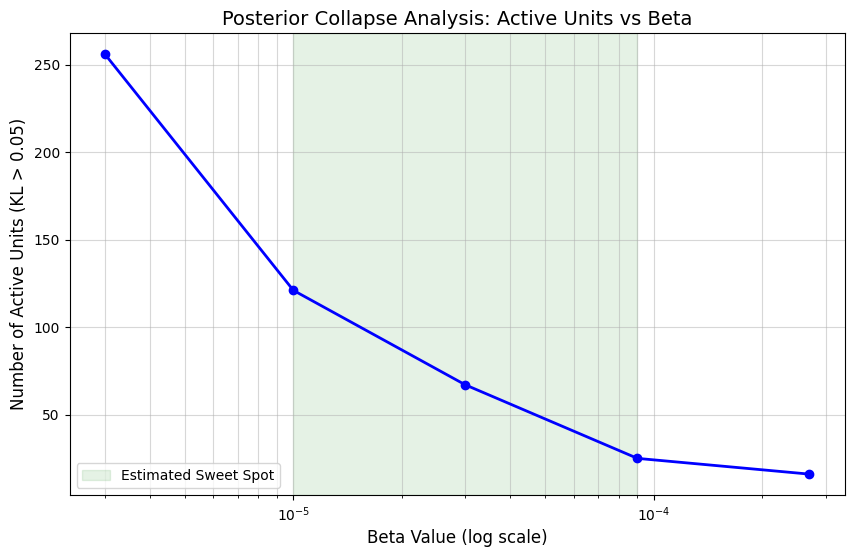

In [12]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))
plt.plot(kl_results_df['beta'], kl_results_df['active_units'], 'o-', linewidth=2, color='b')
plt.xscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel('Beta Value (log scale)', fontsize=12)
plt.ylabel(f'Number of Active Units (KL > {0.05})', fontsize=12)
plt.title(f'Posterior Collapse Analysis: Active Units vs Beta', fontsize=14)

# Highlight the user's estimated optimal range
plt.axvspan(1e-5, 9e-5, color='green', alpha=0.1, label='Estimated Sweet Spot')
plt.legend()

plt.show()

In [13]:
display(kl_results_df)

,beta,active_units,avg_kl
0,0.000003,256,0.535430
1,0.000010,121,0.279552
2,0.000030,67,0.142843
3,0.000090,25,0.065606
4,0.000270,16,0.032742


In [14]:
# Configuration
target_beta = "3.00e-05" # The winner
input_dir = "output/Experiments/BetaScanVAE/latent_representations"
output_dir = "output/Experiments/BetaScanVAE/clean_latents"
os.makedirs(output_dir, exist_ok=True)

def clean_latent_dataframe(beta_str, split="train", threshold=1e-2):
    """
    Loads the Mu CSV, removes columns with variance < threshold (collapsed),
    and saves the cleaned version.
    """
    # Load the raw 256-dim CSV
    file_path = os.path.join(input_dir, f"{split}_mu_beta_{beta_str}.csv")
    df = pd.read_csv(file_path)
    
    # Calculate variance per dimension (column)
    variances = df.var()
    
    # Identify active columns (where variance is sufficiently > 0)
    # Note: 1e-2 is a safe proxy for "collapsed" when looking at Mu variance
    active_cols = variances[variances > threshold].index.tolist()
    
    print(f"[{split}] Original dimensions: {df.shape[1]}")
    print(f"[{split}] Active dimensions (Var > {threshold}): {len(active_cols)}")
    
    # Filter DataFrame
    df_clean = df[active_cols]
    
    # Save
    save_path = os.path.join(output_dir, f"{split}_latents_clean_beta_{beta_str}.csv")
    df_clean.to_csv(save_path, index=False)
    print(f"[{split}] Saved cleaned data to: {save_path}\n")
    
    return active_cols

# 1. Clean Training Data
active_columns = clean_latent_dataframe(target_beta, "train")

# 2. Clean Validation Data (MUST use the same columns as training to keep indices aligned)
# We strictly apply the training columns to the validation set
val_path = os.path.join(input_dir, f"val_mu_beta_{target_beta}.csv")
val_df = pd.read_csv(val_path)
val_df_clean = val_df[active_columns]
val_save_path = os.path.join(output_dir, f"val_latents_clean_beta_{target_beta}.csv")
val_df_clean.to_csv(val_save_path, index=False)
print(f"[val] Applied training mask. Saved to: {val_save_path}")

TypeError: could not convert string to float: 'data/Images/PPMI_Images_PD/219605/Reconstructed_DaTSCAN/2023-04-06_14_52_54.0/I1698019/PPMI_219605_NM_Reconstructed_DaTSCAN_Br_20230508143813985_1_S1220401_I1698019.dcm'